# Lecture 35. 크루스칼 알고리즘

## 0. 목차
1. 신장 트리
2. 최소 신장 트리
3. 크루스칼 알고리즘
4. 크루스칼 알고리즘: 동작 과정 살펴보기
5. 크루스칼 알고리즘: 소스코드
6. 크루스칼 알고리즘 성능 분석

## 1. 신장 트리

- 신장 트리란 그래프에서 모든 노드를 포함하면서 사이클이 존재하지 않는 부분 그래프를 의미한다.
    - 모든 노드가 포함되어 서로 연결되면서 사이클이 존재하지 않는다는 조건은 트리의 조건이기도 하다. 

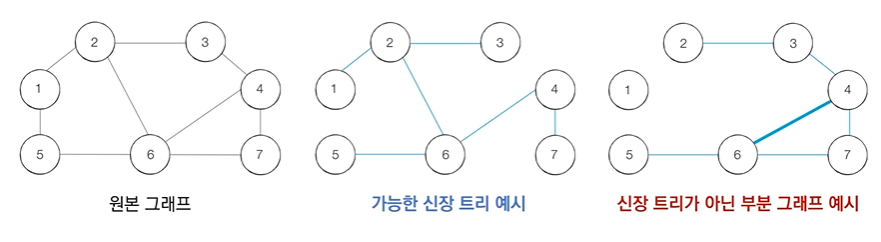

일부 간선을 사용하지 않는다는 아이디어를 이용하는 경우 이를 사용할 수 있다.

## 2. 최소 신장 트리

- 최소한의 비용으로 구성되는 신장 트리를 찾는 것을 최소 신장 트리라고 한다.
- 예를 들어 N개의 도시가 존재하는상황에서 두 도시 사이에 도로를 놓아 전체 도시가 서로 연결될 수 있게 도로를 설치하는 경우가 최소 신장 트리 문제이다.
    - 즉, 두 도시 A, B를 선택했을 때 A에서 B로 이동하는 경로가 반드시 존재하도록 도로를 설치한다.
    - 아래처럼 구성이 되어 있을 때 최소 신장 트리를 찾으면 오른쪽과 같이 두개의 간선만 선택한 결과이다. 이렇게 두 개만 설치하더라도 결과적으로 모든 노드가 연결되어 있고 간선 비용의 합이 가장 적다.

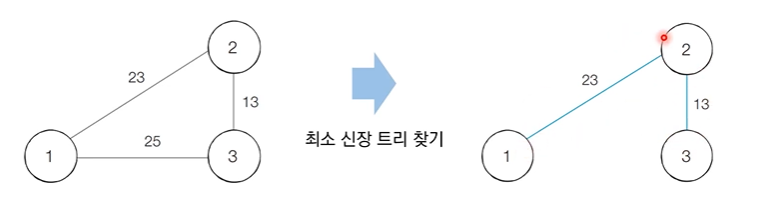

## 3. 크루스칼 알고리즘

- 크루스칼 알고리즘은 대표적인 최소 신장 트리 알고리즘이다. 
- 크루스칼 알고리즘은 그리디 알고리즘으로 분류된다.
- 전체 동작 과정은 다음과 같다.
1. 간선 데이터를 비용에 따라 오름차순으로 정렬한다.
2. 간선을 하나씩 확인하며 현재의 간선이 사이클을 발생시키는지 확인한다.
    1) 사이클이 발생하지 않는 경우 최소 신장 트리에 포함시킨다.
    2) 사이클이 발생하는 경우 최소 신장 트리에 포함시키지 않는다.
3. 모든 간선에 대하여 2번의 과정을 반복한다.

## 4. 크루스칼 알고리즘: 동작 과정 살펴보기

[초기 단계] 그래프의 모든 간선 정보에 대하여 오름차순 정렬을 수행한다.
    - 최종적으로 만들어지는 최소 신장 트리에 포함되어 있는 간선의 개수는 (전체 노드의 개수 - 1)이다.
    - 이는 기본적으로 트리가 가지는 특성이며 사이클이 존재하지 않는다는 특성도 있다.

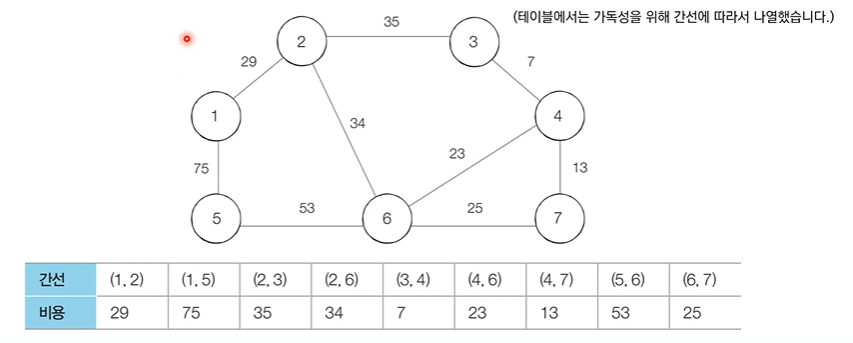


[Step 1] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (3,4)를 선택하여 처리한다.
    - 3, 4번 노드는 같은 집합에 속해있지 않기 때문에 union 함수를 호출한다.

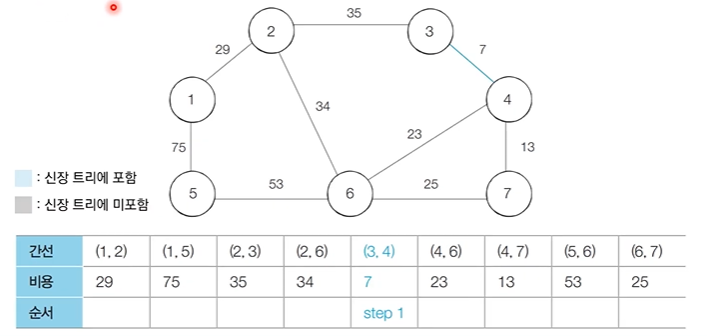

[Step 2] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (4, 7)을 선택하여 처리한다.

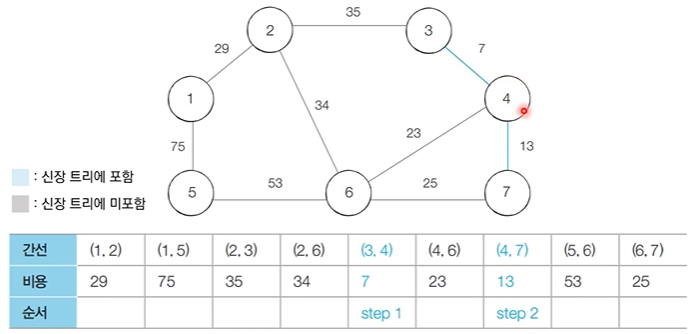

[Step 3] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (4, 6)을 선택하여 처리한다.

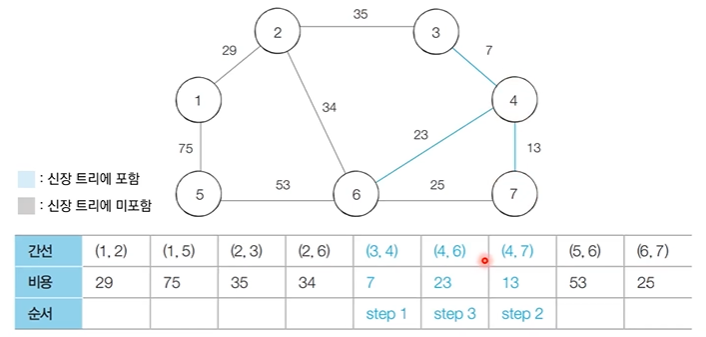

[Step 4] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (6, 7)을 선택하여 처리한다.
    - 같은 집합에 속해있으므로 포함하지 않고 넘어간다.

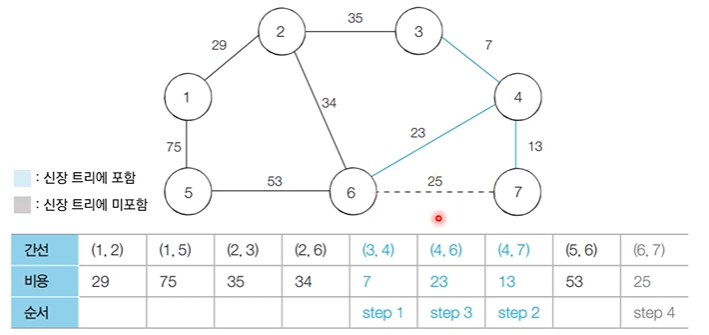

[Step 5] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (1, 2)를 선택하여 처리한다.

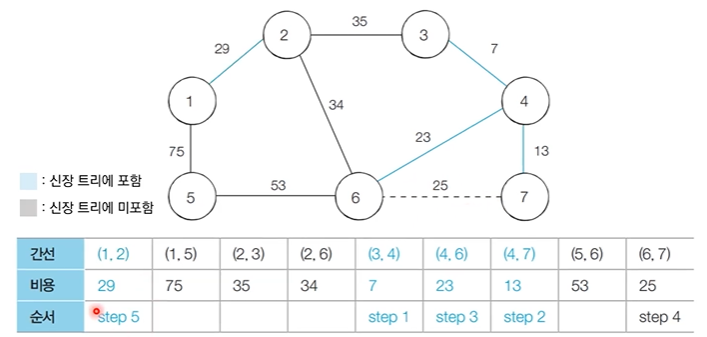

[Step 6] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (2, 6)을 선택하여 처리한다.

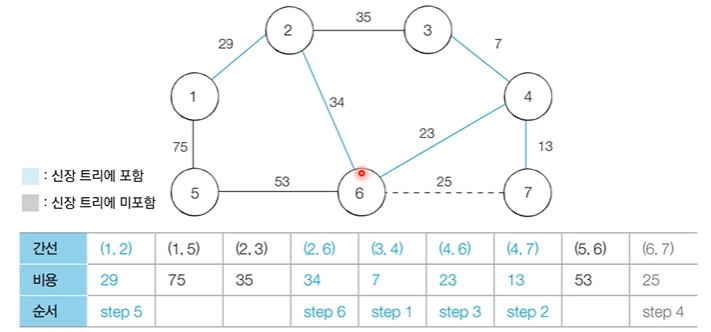

[Step 7] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (2, 3)을 선택하여 처리한다.

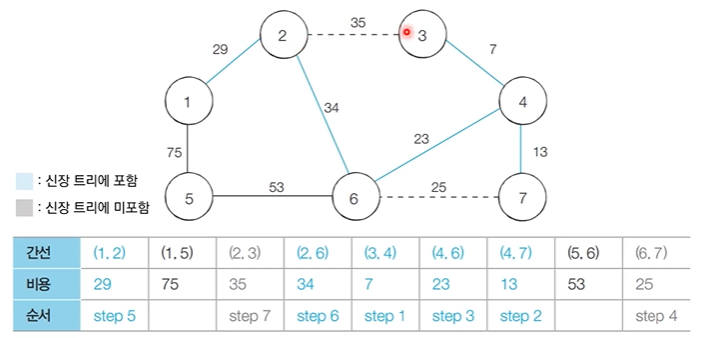

[Step 8] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (5, 6)을 선택하여 처리한다.


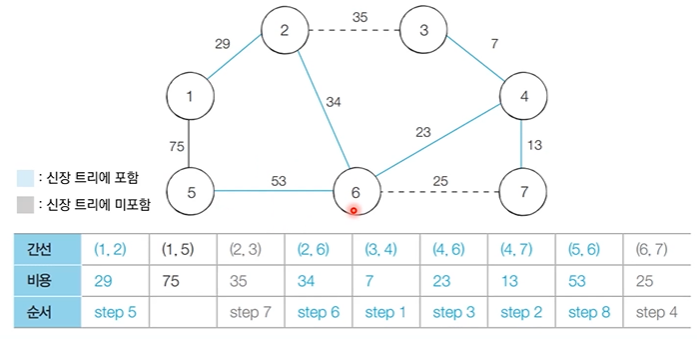

[Step 9] 아직 처리하지 않은 간선 중에서 가장 짧은 간선인 (1, 5)를 선택하여 처리한다.


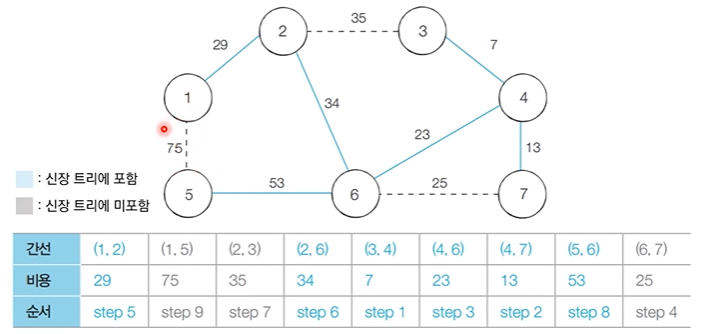

[알고리즘 수행 결과] 최소 신장 트리에 포함되어 있는 간선의 비용만 모두 더하면, 그 값이 최종 비용에 해당한다.

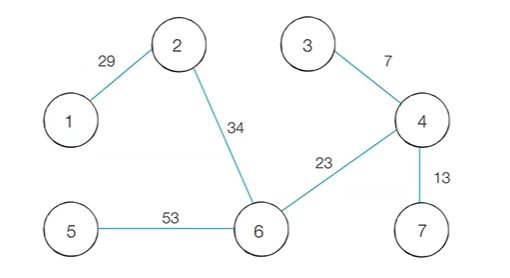

## 5. 크루스칼 알고리즘: 소스코드

### 구현 연습


In [ ]:
# 찾기 함수
def find_parent(parent, x):
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# union 함수
def union(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a > b:
        parent[a] = b
    else:
        parent[b] = a

v, e = map(int, input().split())
parent = [0] * (v+1)
for i in range(1,v+1):
    parent[i] = i

result = []

for i in range(e):
    a, b, cost = map(int, input().split())
    result.append((cost, a, b))

result.sort()
sum = 0

for cost, a, b in range(result):
    if find_parent(parent, a) != find_parent(parent, b):
        union(parent, a, b)
        sum += cost
    else:
        continue

print(sum)

### 장답

```python
# 특정 원소가 속한 집합을 찾기
def find_parent(parent, x):
    # 루트 노드를 찾을 때까지 재귀 호출
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# 두 원소가 속한 집합을 합치기
def union_parent(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a < b:
        parent[b] = a
    else:
        parent[a] = b

# 노드의 개수와 간선(Union 연산)의 개수 입력 받기
v, e = map(int, input().split())
parent = [0] * (v+1) # 부모 테이블 초기화

# 모든 간선을 담을 리스트와, 최종 비용을 담을 변수
edges = []
result = 0

# 부모 테이블상에서, 부모를 자기 자신으로 초기화
for i in range(1, v+1):
    parent[i] = i

# 모든 간선에 대한 정보를 입력 받기
for _ in range(e):
    a, b, cost = map(int, input().split())
    # 비용순으로 정렬하기 위해서 튜플의 첫 번째 원소를 비용으로 설정
    edges.append((cost, a, b))

# 간선을 비용순으로 정렬
edges.sort()

# 간선을 하나씩 확인하며
for edge in edges:
    cost, a, b = edge
    # 사이클이 발생하지 않은 경우에만 집합에 포함
    if find_parent(parent, a) != find_parent(parent, b):
        union_parent(parent, a, b)
        result += cost

print(result)
```
#### 내 코드의 부족한 부분

```

작성하신 코드는 **크루스칼 알고리즘(Kruskal's Algorithm)**의 핵심 로직을 아주 잘 파악하고 계시네요! 하지만 실제 실행을 해보면 **단 한 부분**에서 에러가 발생하여 코드가 멈출 거예요.

가장 결정적인 오류와 몇 가지 개선하면 좋을 점을 짚어 드릴게요.

---

### 1. 치명적인 오류: `for`문 반복 방식
가장 먼저 수정해야 할 부분은 마지막 `for`문입니다.

* **잘못된 코드:** `for cost, a, b in range(result):`
* **원인:** `range()` 함수는 인자로 **정수(int)**를 받아야 합니다. 하지만 `result`는 간선 정보가 담긴 **리스트(list)**이기 때문에 여기서 `TypeError`가 발생합니다.
* **수정 방법:** 리스트의 요소를 직접 꺼내오도록 수정해야 합니다.
    ```python
    for cost, a, b in result:  # range()를 빼고 리스트 자체를 순회합니다.
    ```

### 2. 소소한 권장 사항: 예약어 사용 피하기
코드에서 `sum`이라는 변수명을 사용하셨는데요.

* **이유:** `sum`은 파이썬의 **내장 함수(Built-in function)** 이름입니다. 변수명으로 사용해도 당장 에러가 나지는 않지만, 나중에 실제 합계 함수인 `sum()`을 호출해야 할 때 문제가 생길 수 있습니다.
* **수정 제안:** `total_cost`나 `ans` 같은 이름을 추천드려요.

### 3. 로직 비교 (정답 코드 vs 작성하신 코드)
`union` 함수 내부에서 `a < b`일 때와 `a > b`일 때 처리하는 방식이 정답 코드와 반대로 되어 있지만, 이는 **일관성만 있다면 결과에 아무런 영향을 주지 않습니다.** 작은 번호를 부모로 할지, 큰 번호를 부모로 할지의 차이일 뿐입니다.

---

### 수정한 최종 코드
위의 내용을 반영하여 수정한 코드는 다음과 같습니다.

    ```python
# 찾기 함수 (경로 압축 적용 - 아주 잘 작성하셨습니다!)
def find_parent(parent, x):
    if parent[x] != x:
        parent[x] = find_parent(parent, parent[x])
    return parent[x]

# union 함수
def union(parent, a, b):
    a = find_parent(parent, a)
    b = find_parent(parent, b)
    if a > b:
        parent[a] = b
    else:
        parent[b] = a

v, e = map(int, input().split())
parent = [0] * (v+1)
for i in range(1, v+1):
    parent[i] = i

edges = [] # 변수명을 result에서 edges로 바꾸면 좀 더 명확해요

for i in range(e):
    a, b, cost = map(int, input().split())
    edges.append((cost, a, b))

edges.sort()
total_sum = 0 # sum 대신 total_sum 사용

# 핵심 수정 부분: range(result) -> edges
for cost, a, b in edges:
    if find_parent(parent, a) != find_parent(parent, b):
        union(parent, a, b)
        total_sum += cost
    # else: continue 부분은 없어도 무방합니다.

print(total_sum)
    ```

**결론:** `for`문의 `range()` 사용법만 고치면 완벽합니다! 크루스칼의 핵심인 정렬과 Union-Find 구조를 아주 정확하게 이해하고 계시네요.

```
요약 

잘못 구현한 부분은 다음과 같다.
1. 간선 정보를 가져와서 for문을 돌릴 때, range함수를 사용함. 
2. sum으로 변수명 설정함.

## 6. 크루스칼 알고리즘 성능 분석

- 크루스칼 알고리즘은 간선의 개수가 E개일 때, $O(E \log E)$의 시간 복잡도를 가진다.
- 크루스칼 알고리즘에서 가장 많은 시간을 요구하는 곳은 간선을 정렬을 수행하는 부분이다.
    - 표준 라이브러리를 이용해 E개의 데이터를 정렬하기 위한 시간 복잡도는 $O(E \log E)$이다.


## 정리 및 회고

### 순서
1. 신장 트리
2. 최소 신장 트리
3. 크루스칼 알고리즘
4. 크루스칼 알고리즘: 동작 과정 살펴보기
5. 크루스칼 알고리즘: 소스코드
6. 크루스칼 알고리즘 성능 분석

### 키워드
신장 트리, 최소 신장 트리, 크루스칼 알고리즘

### 회고
1. 서로소 집합 알고리즘이 계속 쓰여서 생각보다 쉽게 느껴진다. 